In [48]:
import numpy as np
from matplotlib import pyplot as plt

import astropy.units as u

from lenstronomy.Data.coord_transforms import Coordinates
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
import lenstronomy.Util.image_util as image_util
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.LightModel.Profiles.sersic import SersicElliptic

import os
import copy

from lenstronomy.Plots.model_band_plot import ModelBandPlot

cwd = os.getcwd()
cwd

'/Users/admin/Documents/SED_inferred_color_images'

In [3]:
from astropy.cosmology import wCDM

Om = 0.3
w = -1
custom_cosmo = wCDM(H0=70 * u.km / u.s / u.Mpc, Om0=Om, Ob0=0.05, Ode0=1-Om, w0=w)

z_l = 0.85
z_s = 2.4

In [152]:
import pickle

input_name = 'opt_5'

# load kwargs
with open(f'{cwd}/../creating_spiral_images/{input_name}/kwargs.pkl', 'rb') as f:
    data = pickle.load(f)
    kwargs_params_in, kwargs_model_in, multiband_list_in = data['params'], data['models'], data['multiband_list']

kwargs_model_in['lens_model_list'] = ['SIE'] + kwargs_model_in['lens_model_list'][2:]

kwargs_params_in['kwargs_lens'] = [{'theta_E': 1.8, 'center_x': kwargs_params_in['kwargs_lens'][0]['center_x'], 'center_y': kwargs_params_in['kwargs_lens'][0]['center_y'],
                                    'e1': kwargs_params_in['kwargs_lens'][0]['e1'], 'e2': kwargs_params_in['kwargs_lens'][0]['e2']}
                                    ] + kwargs_params_in['kwargs_lens'][2:]

kwargs_params_in['kwargs_lens_light'] = [{
    'amp': 1,
    'R_sersic': 2.5,
    'n_sersic': 4,
    'e1': kwargs_params_in['kwargs_lens_light'][0]['e1'],
    'e2': kwargs_params_in['kwargs_lens_light'][0]['e2'],
    'center_x': kwargs_params_in['kwargs_lens_light'][0]['center_x'],
    'center_y': kwargs_params_in['kwargs_lens_light'][0]['center_y']
}]

kwargs_params_in['kwargs_source'][0]['R_sersic'] = 0.2
kwargs_params_in['kwargs_source'][0]['n_sersic'] = 1.5
kwargs_params_in['kwargs_source'][0]['center_x'] = 0.25
kwargs_params_in['kwargs_source'][0]['center_y'] = 0.15

print(f'Currently loaded model is {input_name}')

Currently loaded model is opt_5


In [193]:
kwargs_params_in

{'kwargs_lens': [{'theta_E': 1.8,
   'center_x': 0.3686891993185043,
   'center_y': -0.040460506267520104,
   'e1': -0.1,
   'e2': 0.2},
  {'theta_E': 0.4,
   'center_x': 0.3686891993185043,
   'center_y': -0.040460506267520104},
  {'gamma_ext': 0.06, 'psi_ext': -24.700847167862154, 'ra_0': 0, 'dec_0': 0}],
 'kwargs_source': [{'amp': 1000000.0,
   'R_sersic': 0.2,
   'n_sersic': 1.5,
   'e1': -0.1,
   'e2': -0.7,
   'center_x': 0.25,
   'center_y': 0.15}],
 'kwargs_lens_light': [],
 'kwargs_ps': [],
 'kwargs_special': {},
 'kwargs_extinction': [],
 'kwargs_tracer_source': []}

In [153]:
exp_time = 600
bkg_rms = 0.04

NIR_pixel_scale = 0.3
NIR_num_pix = 150
NIR_psf_fwhm = [0.475, 0.504, 0.542]

VIS_pixel_scale = 0.1
VIS_num_pix = 200#int(NIR_num_pix * round(NIR_pixel_scale / VIS_pixel_scale))
VIS_psf_fwhm = 0.203

In [154]:
kwargs_params_in['kwargs_lens_light'] = []
kwargs_model_in['lens_light_model_list'] = []

kwargs_params_in['kwargs_source'][0]['amp'] = 1

z_l_list = [z_l for i in range(len(kwargs_model_in['lens_model_list']))]
z_s_list = [z_s for i in range(len(kwargs_model_in['source_light_model_list']))]
z_l_list, z_s_list

([0.85, 0.85, 0.85], [2.4])

In [192]:
kwargs_data = {
    'background_rms': bkg_rms,  # rms of background noise
    'exposure_time': exp_time,  # exposure time (or a map per pixel)
    'ra_at_xy_0': -VIS_num_pix*VIS_pixel_scale/2,  # RA at (0,0) pixel
    'dec_at_xy_0': -VIS_num_pix*VIS_pixel_scale/2,  # DEC at (0,0) pixel
    'transform_pix2angle': np.array([[VIS_pixel_scale, 0], [0, VIS_pixel_scale]]),  # matrix to translate shift in pixel in shift in relative RA/DEC (2x2 matrix). Make sure it's units are arcseconds or the angular units you want to model.
    'image_data': np.zeros((VIS_num_pix, VIS_num_pix))
}

kwargs_psf = {
    'psf_type': 'GAUSSIAN', 
    'fwhm': VIS_psf_fwhm, 
    'pixel_size': VIS_pixel_scale, 
    'truncation': 12
    }

kwargs_numerics = {'supersampling_factor': 3, 'supersampling_convolution': True}

kwargs_pixel = {'nx': VIS_num_pix, 'ny': VIS_num_pix,  # number of pixels per axis
            'ra_at_xy_0': kwargs_data['ra_at_xy_0'],  # RA at pixel (0,0)
            'dec_at_xy_0': kwargs_data['dec_at_xy_0'],  # DEC at pixel (0,0)
            'transform_pix2angle': kwargs_data['transform_pix2angle']}

pixel_grid = PixelGrid(**kwargs_pixel)
coords = Coordinates(kwargs_pixel['transform_pix2angle'], kwargs_pixel['ra_at_xy_0'], kwargs_pixel['dec_at_xy_0'])

data_class = ImageData(**kwargs_data)
psf_class = PSF(**kwargs_psf)

lens_model_class = LensModel(kwargs_model_in['lens_model_list'], lens_redshift_list=z_l_list, cosmo=custom_cosmo)
source_model_class = LightModel(kwargs_model_in['source_light_model_list'], source_redshift_list=z_s_list)
lens_light_model_class = LightModel(kwargs_model_in['lens_light_model_list'])

print(kwargs_model_in['lens_model_list'])

image_model = ImageModel(data_class, psf_class, lens_model_class=lens_model_class, 
                    source_model_class=source_model_class, lens_light_model_class=lens_light_model_class,
                    kwargs_numerics=kwargs_numerics)

pos_x, pos_y = lens_model_class.ray_shooting(
            pixel_grid._x_grid, pixel_grid._y_grid, kwargs_params_in['kwargs_lens']
        )
SE = SersicElliptic()
mu = lens_model_class.magnification(x=pixel_grid._x_grid, y=pixel_grid._y_grid, kwargs=kwargs_params_in['kwargs_lens'])

amplitudes = np.logspace(0, 6, 10)#[8.61017669e-01, 6.83929600e+02, 1.10569206e+03, 2.74667085e+03]

counts = []
mu_ws = []

for amp in amplitudes:
    kwargs_params_in['kwargs_source'][0]['amp'] = amp
    counts.append(np.sum(image_model.image(kwargs_params_in['kwargs_lens'], kwargs_params_in['kwargs_source'], kwargs_lens_light=None, kwargs_ps=None)))

    
    surface_brightness = SE.function(pos_x, pos_y, **kwargs_params_in['kwargs_source'][0])
    

    mu_ws.append(np.sum(surface_brightness * mu) / np.sum(surface_brightness))

counts = np.array(counts) * VIS_pixel_scale**2
mu_ws = np.array(mu_ws)

# generate image
image_model = image_model.image(kwargs_params_in['kwargs_lens'], kwargs_params_in['kwargs_source'], kwargs_lens_light=kwargs_params_in['kwargs_lens_light'], kwargs_ps=None)

kwargs_data['image_data'] = image_model


['SIE', 'POINT_MASS', 'SHEAR_GAMMA_PSI']


In [156]:
pixel_grid._x_grid.shape, pixel_grid._y_grid.shape

((200, 200), (200, 200))

In [157]:
mu_ws = np.array(mu_ws)
mu_ws

array([-2.47460171, -2.47460171, -2.47460171, -2.47460171, -2.47460171,
       -2.47460171, -2.47460171, -2.47460171, -2.47460171, -2.47460171])

In [158]:
if counts.shape[0] == 4:
    zp = np.array([25.74, 29.8, 30.0, 29.9])

    mags = - 2.5 * np.log10(counts) + zp
    mags

In [184]:
from scipy.special import gamma

def sersic_total_flux(R_sersic, n_sersic, e1 , e2, amplitude=1):
    k_n = 1.9992 * n_sersic - 0.3271  # approximate
    q = (1-np.sqrt(e1**2 + e2**2)) / (1+np.sqrt(e1**2 + e2**2))
    return 2 * np.pi * R_sersic**2 * q * n_sersic * np.exp(k_n) * gamma(2 * n_sersic) / k_n**(2 * n_sersic) * amplitude

source_flux = sersic_total_flux(
    kwargs_params_in['kwargs_source'][0]['R_sersic'], 
    kwargs_params_in['kwargs_source'][0]['n_sersic'], 
    kwargs_params_in['kwargs_source'][0]['e1'], 
    kwargs_params_in['kwargs_source'][0]['e2'],
    amplitude=amplitudes)

-2.5*np.log10(counts)+25, counts

(array([28.03481874, 26.36815208, 24.70148541, 23.03481874, 21.36815208,
        19.70148541, 18.03481874, 16.36815208, 14.70148541, 13.03481874]),
 array([6.11044026e-02, 2.83621513e-01, 1.31645445e+00, 6.11044026e+00,
        2.83621513e+01, 1.31645445e+02, 6.11044026e+02, 2.83621513e+03,
        1.31645445e+04, 6.11044026e+04]))

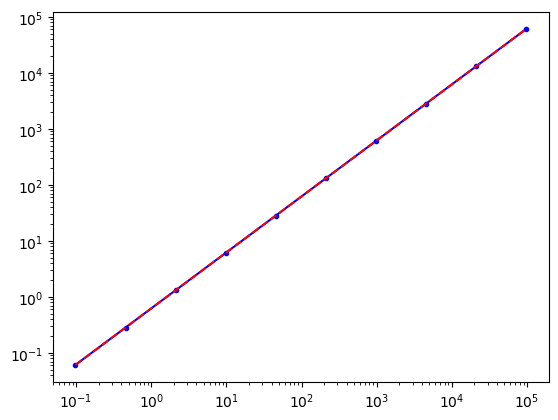

In [160]:
def linear(x, a, b):
    return a * x + b

from scipy.optimize import curve_fit

plt.plot(source_flux, counts, marker='.', c='b')


# Fit the data to the linear model
popt, pcov = curve_fit(linear, np.log10(source_flux), np.log10(counts))

# Plot the fitted line
plt.plot(source_flux, 10**linear(np.log10(source_flux), *popt), linestyle='--', color='red')

plt.xscale('log')
plt.yscale('log')
plt.show()

In [144]:
popt, pcov, 10**popt[1]

(array([ 1.        , -0.06350206]),
 array([[ 5.25253705e-35, -1.03313542e-34],
        [-1.03313542e-34,  3.95803109e-34]]),
 0.8639685551842357)

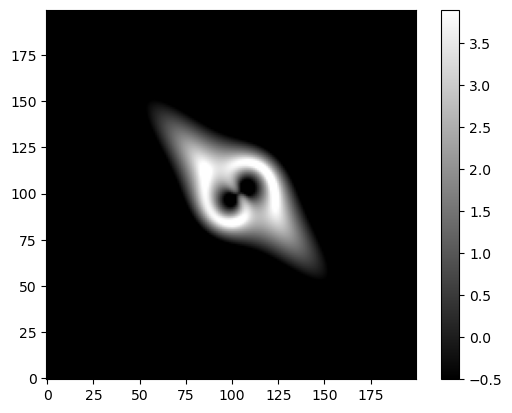

6110440.2634699745

In [179]:
plt.imshow(np.log10(kwargs_data['image_data']), origin='lower', cmap='gray',  vmin=-0.5, vmax=3.9)
plt.colorbar()
plt.show()
np.sum(kwargs_data['image_data'])

In [173]:
np.max(np.log10(kwargs_data['image_data']))

4.6451747077062935

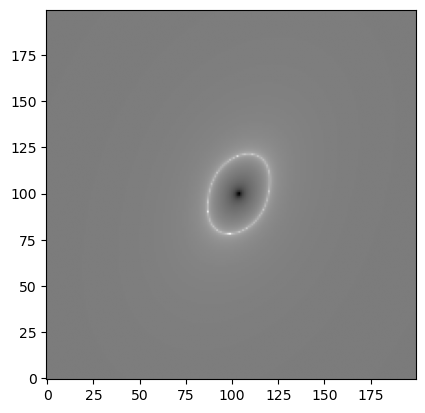

In [146]:
import lenstronomy.Util.util as util

plt.imshow(np.log10(np.abs(lens_model_class.magnification(x=pixel_grid._x_grid, y=pixel_grid._y_grid, kwargs=kwargs_params_in['kwargs_lens']))), origin='lower', cmap='gray')


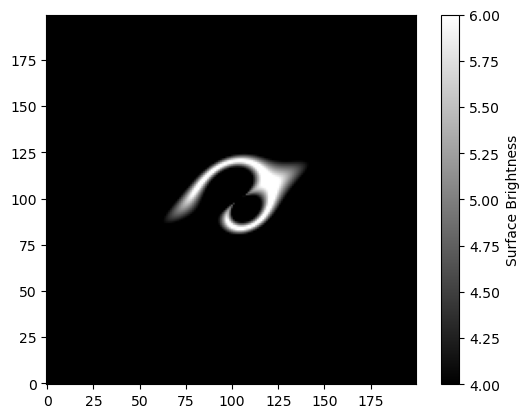

In [147]:
pos_x, pos_y = lens_model_class.ray_shooting(
            pixel_grid._x_grid, pixel_grid._y_grid, kwargs_params_in['kwargs_lens']
        )
SE = SersicElliptic()
plt.imshow(np.log10(SE.function(pos_x, pos_y, **kwargs_params_in['kwargs_source'][0])), origin='lower', cmap='gray', vmin=4, vmax=6)
plt.colorbar(label='Surface Brightness')
plt.show()

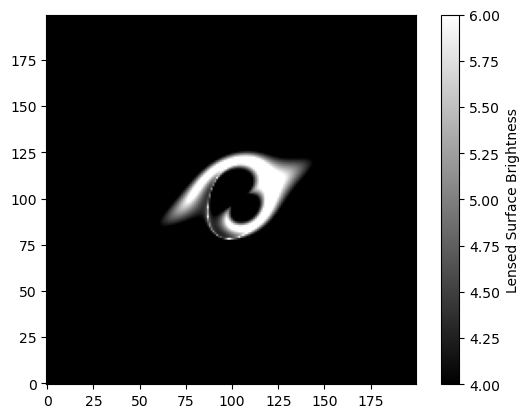

In [148]:
plt.imshow(np.log10(SE.function(pos_x, pos_y, **kwargs_params_in['kwargs_source'][0]) * np.abs(lens_model_class.magnification(x=pixel_grid._x_grid, y=pixel_grid._y_grid, kwargs=kwargs_params_in['kwargs_lens']))), origin='lower', cmap='gray', vmin=4, vmax=6)
plt.colorbar(label='Lensed Surface Brightness')
plt.show()

In [149]:
S = SE.function(pos_x, pos_y, **kwargs_params_in['kwargs_source'][0])
mu = lens_model_class.magnification(x=pixel_grid._x_grid, y=pixel_grid._y_grid, kwargs=kwargs_params_in['kwargs_lens'])

mu_weighted = np.sum(S * mu) / np.sum(S)
mu_weighted

4.6978939664261405

In [150]:
kwargs_params_in['kwargs_source'], kwargs_model_in['lens_model_list']

([{'amp': 1000000.0,
   'R_sersic': 0.2,
   'n_sersic': 1.5,
   'e1': 0.4,
   'e2': 0.6,
   'center_x': 0.25,
   'center_y': 0.15}],
 ['SIE', 'POINT_MASS', 'SHEAR_GAMMA_PSI'])

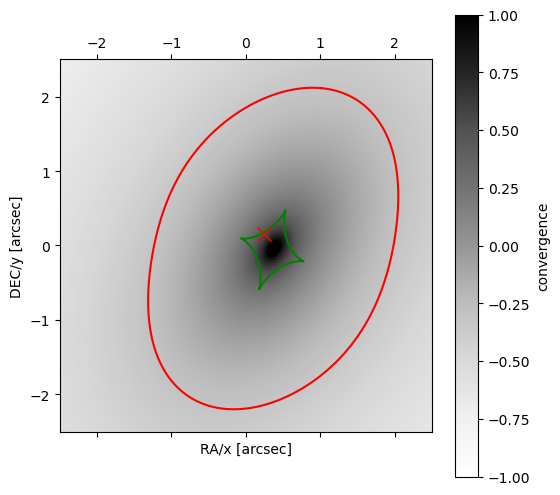

In [151]:
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# make sure you use same lens_model_list and kwargs_lens
lens_model = LensModel(lens_model_list=['SIE', 'POINT_MASS', 'SHEAR_GAMMA_PSI'])
lens_plot.lens_model_plot(ax, lens_model, kwargs_params_in['kwargs_lens'], with_caustics=True)
plt.colorbar(label='convergence', mappable=ax.images[0], ax=ax)
ax.plot(kwargs_params_in['kwargs_source'][0]['center_x'], kwargs_params_in['kwargs_source'][0]['center_y'], marker='x', color='red', markersize=10)

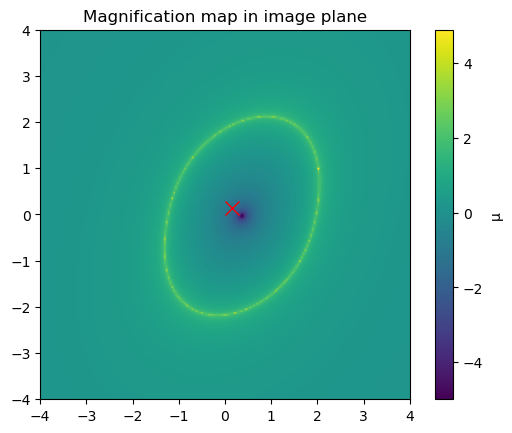

In [134]:
# grid of source positions
bounds = 4.0
x = np.linspace(-bounds, bounds, 200)
y = np.linspace(-bounds, bounds, 200)
X, Y = np.meshgrid(x, y)
mu = lens_model.magnification(X, Y, kwargs_params_in['kwargs_lens'])

plt.imshow(np.log10(np.abs(mu)), origin='lower', extent=(-bounds, bounds, -bounds, bounds))
plt.colorbar(label='μ')
plt.plot(kwargs_params_in['kwargs_source'][0]['center_x'], kwargs_params_in['kwargs_source'][0]['center_y'], marker='x', color='red', markersize=10)
plt.title('Magnification map in image plane')
plt.show()

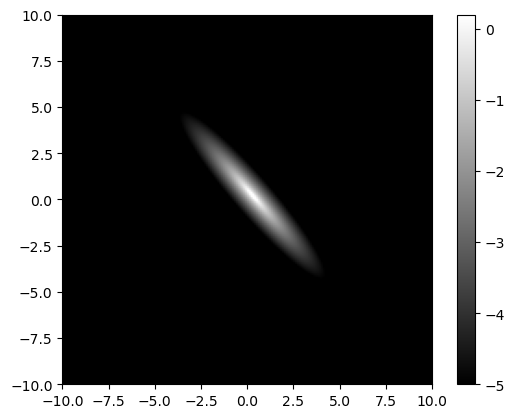

In [191]:
# create image of just source no lensing
SE = SersicElliptic()
kwargs_params_in['kwargs_source'][0]['amp'] = 1
source_image = SE.function(pixel_grid._x_grid, pixel_grid._y_grid, **kwargs_params_in['kwargs_source'][0])
extent = (-0.5*VIS_num_pix*VIS_pixel_scale, 0.5*VIS_num_pix*VIS_pixel_scale, -0.5*VIS_num_pix*VIS_pixel_scale, 0.5*VIS_num_pix*VIS_pixel_scale)
plt.imshow(np.log10(np.abs(source_image)), origin='lower', cmap='gray', extent=extent, vmin=-5, vmax=0.2)
plt.colorbar()